## 1. Create synthetic ObsPy streams

Create two streams with five stations, three minutes of data, and a sampling rate of 100 Hz.

In [1]:
import numpy as np
from obspy import Stream, Trace
from obspy.core import UTCDateTime

sampling_rate = 100.0  # Hz
duration = 3 * 60       # seconds
n_samples = int(sampling_rate * duration)
stations = [f"S{i}" for i in range(1, 6)]
starttime = UTCDateTime("2025-01-01T00:00:00")
rng = np.random.default_rng(42)
time = np.arange(n_samples) / sampling_rate

st1 = Stream()
st2 = Stream()

for station in stations:
    signal1 = (
        0.8 * np.sin(2 * np.pi * 2.0 * time)
        + 0.2 * rng.normal(size=n_samples)
    )
    signal2 = (
        0.5 * np.sin(2 * np.pi * 2.0 * time + 0.1)
        + 0.2 * rng.normal(size=n_samples)
    )

    tr1 = Trace(data=signal1.astype(np.float64))
    tr1.stats.station = station
    tr1.stats.network = "XX"
    tr1.stats.channel = "BHZ"
    tr1.stats.starttime = starttime
    tr1.stats.sampling_rate = sampling_rate
    tr1.stats.t0 = 100.0

    tr2 = Trace(data=signal2.astype(np.float64))
    tr2.stats.station = station
    tr2.stats.network = "XX"
    tr2.stats.channel = "BHZ"
    tr2.stats.starttime = starttime
    tr2.stats.sampling_rate = sampling_rate
    tr2.stats.t0 = 100.0

    st1.append(tr1)
    st2.append(tr2)


In [2]:
assert len(st1) == 5 and len(st2) == 5
assert [tr.stats.station for tr in st1] == stations
assert [tr.stats.station for tr in st2] == stations
assert all(tr.stats.npts == 18000 for tr in st1 + st2)
assert all(tr.stats.sampling_rate == 100.0 for tr in st1 + st2)
assert all(tr.stats.t0 == 100.0 for tr in st1 + st2)

print(st1)
print(st2)
print("Synthetic stream checks passed.")


5 Trace(s) in Stream:
XX.S1..BHZ | 2025-01-01T00:00:00.000000Z - 2025-01-01T00:02:59.990000Z | 100.0 Hz, 18000 samples
XX.S2..BHZ | 2025-01-01T00:00:00.000000Z - 2025-01-01T00:02:59.990000Z | 100.0 Hz, 18000 samples
XX.S3..BHZ | 2025-01-01T00:00:00.000000Z - 2025-01-01T00:02:59.990000Z | 100.0 Hz, 18000 samples
XX.S4..BHZ | 2025-01-01T00:00:00.000000Z - 2025-01-01T00:02:59.990000Z | 100.0 Hz, 18000 samples
XX.S5..BHZ | 2025-01-01T00:00:00.000000Z - 2025-01-01T00:02:59.990000Z | 100.0 Hz, 18000 samples
5 Trace(s) in Stream:
XX.S1..BHZ | 2025-01-01T00:00:00.000000Z - 2025-01-01T00:02:59.990000Z | 100.0 Hz, 18000 samples
XX.S2..BHZ | 2025-01-01T00:00:00.000000Z - 2025-01-01T00:02:59.990000Z | 100.0 Hz, 18000 samples
XX.S3..BHZ | 2025-01-01T00:00:00.000000Z - 2025-01-01T00:02:59.990000Z | 100.0 Hz, 18000 samples
XX.S4..BHZ | 2025-01-01T00:00:00.000000Z - 2025-01-01T00:02:59.990000Z | 100.0 Hz, 18000 samples
XX.S5..BHZ | 2025-01-01T00:00:00.000000Z - 2025-01-01T00:02:59.990000Z | 100.0 Hz, 

## 2. Phase coherence

Calculate the interstation phase coherence for the synthetic waveforms.

This is just to check that the code _runs_.  It may or may not actually work.

The cross spectra have shape
(72, 5, 1)


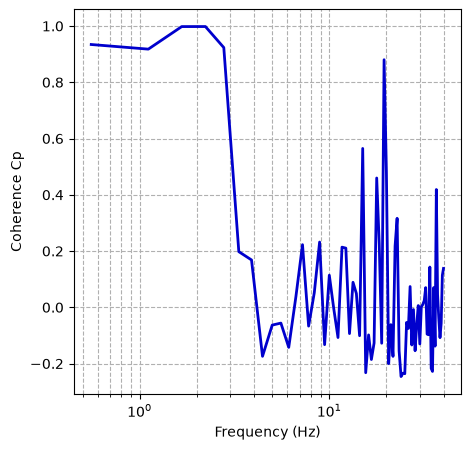

In [3]:
import matplotlib.pyplot as plt
import phscoh

# Compute the cross-spectra using the t0 picks set above.
xc = phscoh.calcxc(
    st1,
    st2,
    trange=[0.0, 1.8],
    mk1="t0",
    mk2="t0",
    tpr="cosine",
)

print("The cross spectra have shape")
print(xc.xc.shape)

# Calculate moveout and phase coherence.
xc.calcmvout()
xc.cpfromr()

plt.figure(figsize=(5, 5))
plt.plot(xc.freq, xc.Cp, linewidth=2.0, color="mediumblue")
plt.xscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Coherence Cp")
plt.grid(True, which="both", linestyle="--")
plt.show()
